<a href="https://colab.research.google.com/github/adityainnet/Loan-Approval-Prediction-using-ML/blob/main/Loan_Approval_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/loan_prediction.csv")

In [3]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [4]:
df.shape

(614, 13)

In [5]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [7]:
pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage': (df.isnull().sum()/len(df))*100
}).sort_values(by='Percentage', ascending=False)

,Missing Values,Percentage
Credit_History,50,8.143322
Self_Employed,32,5.211726
LoanAmount,22,3.583062
Dependents,15,2.442997
Loan_Amount_Term,14,2.280130
Gender,13,2.117264
Married,3,0.488599
Education,0,0.000000
Loan_ID,0,0.000000
CoapplicantIncome,0,0.000000


In [8]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


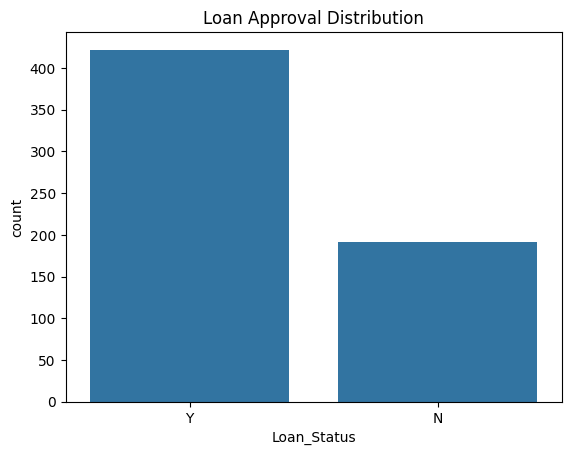

In [9]:
sns.countplot(data=df, x='Loan_Status')
plt.title("Loan Approval Distribution")
plt.show()

In [10]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [11]:
for col in df.select_dtypes(include='object').columns:
    print("\n", col)
    print(df[col].value_counts())


 Loan_ID
Loan_ID
LP002990    1
LP001002    1
LP001003    1
LP001005    1
LP001006    1
           ..
LP001024    1
LP001020    1
LP001018    1
LP001014    1
LP001013    1
Name: count, Length: 614, dtype: int64

 Gender
Gender
Male      489
Female    112
Name: count, dtype: int64

 Married
Married
Yes    398
No     213
Name: count, dtype: int64

 Dependents
Dependents
0     345
1     102
2     101
3+     51
Name: count, dtype: int64

 Education
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

 Self_Employed
Self_Employed
No     500
Yes     82
Name: count, dtype: int64

 Property_Area
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

 Loan_Status
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [12]:
df = df.drop('Loan_ID', axis=1)

In [13]:
num_cols = ['LoanAmount','Loan_Amount_Term','Credit_History']

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [14]:
cat_cols = ['Gender','Married','Dependents','Self_Employed']

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [15]:
df.isnull().sum()

,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0
Credit_History,0


In [16]:
df['Loan_Status'] = df['Loan_Status'].map({
    'Y':1,
    'N':0
})

In [17]:
df['Loan_Status'].value_counts()

,count
Loan_Status,
1,422
0,192


In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

In [19]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,1,0,0,0,0,5849,0.0,128.0,360.0,1.0,2,1
1,1,1,1,0,0,4583,1508.0,128.0,360.0,1.0,0,0
2,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,1,1,0,1,0,2583,2358.0,120.0,360.0,1.0,2,1
4,1,0,0,0,0,6000,0.0,141.0,360.0,1.0,2,1


In [20]:
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [23]:
!pip install imbalanced-learn

In [24]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

In [25]:
from collections import Counter

print("Before SMOTE:")
print(Counter(y_train))

print("\nAfter SMOTE:")
print(Counter(y_train_smote))

Before SMOTE:
Counter({1: 337, 0: 154})

After SMOTE:
Counter({1: 337, 0: 337})


In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_lr))

Accuracy : 0.8373983739837398
Precision: 0.8494623655913979
Recall   : 0.9294117647058824
F1 Score : 0.8876404494382022
ROC AUC  : 0.8334365325077401


In [27]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote, y_train_smote)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_dt))

Accuracy : 0.7073170731707317
Precision: 0.8356164383561644
Recall   : 0.7176470588235294
F1 Score : 0.7721518987341772
ROC AUC  : 0.7009287925696595


In [28]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf.fit(X_train_smote, y_train_smote)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.8048780487804879
Precision: 0.8426966292134831
Recall   : 0.8823529411764706
F1 Score : 0.8620689655172413
ROC AUC  : 0.7724458204334366


In [29]:
results = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Decision Tree',
              'Random Forest'],

    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],

    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],

    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results.sort_values(by='ROC-AUC', ascending=False)

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.849462,0.929412,0.887640,0.833437
2,Random Forest,0.842697,0.882353,0.862069,0.772446
1,Decision Tree,0.835616,0.717647,0.772152,0.700929


In [30]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(10)

,Feature,Importance
9,Credit_History,0.211463
5,ApplicantIncome,0.203528
7,LoanAmount,0.175169
6,CoapplicantIncome,0.106663
10,Property_Area,0.084558
2,Dependents,0.075341
8,Loan_Amount_Term,0.038593
1,Married,0.036788
3,Education,0.028628
4,Self_Employed,0.019783


In [31]:
import pickle

pickle.dump(lr, open('loan_approval_model.pkl', 'wb'))